# Deep Learning - Predicting Proteome from Transcriptome

## Dependency import

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load Data

**NOTE:** Lines of this dataset are outputs of the `RnaToProteinDataModule/scripts/5x2/5x2_run.py` script. The bash script for iteratively running this script is found in the same directory (`5x2_batch.sh`, which in turn calls `_5x2_main_code_run.sh`). The comma-delimited outputs are printed to the screen, then manually configured into a .csv file.

In [15]:
df = pd.read_csv('figure1_datasets/2024_03_26__5x2_output.csv')
df = df.sort_values('val',ascending=False)
df

,dataset,datasetIteration,model,orientation,trainingType,val
6143,lscc,67,baseNN,second,justTargetDataset,412.781457
4167,ccrcc,18,baseNN,second,justTargetDataset,408.063112
4183,lscc,18,baseNN,second,justTargetDataset,405.900622
7343,lscc,97,baseNN,second,justTargetDataset,402.711117
6941,lscc,87,baseNN,first,justTargetDataset,392.435939
...,...,...,...,...,...,...
875,lscc,26,NAS14NN,first,allDatasets,0.436100
3137,hnscc,91,NAS14NN,second,allDatasets,0.361287
3279,gbm,95,NAS14NN,first,allDatasets,0.332763
377,gbm,11,NAS14NN,second,allDatasets,0.320088


### Filter out bad values

In [16]:
#df = df[df['dataset'] != 'coad']
#df = df[df['dataset'] != 'pdac']
df = df[df['dataset'] != 'all']
df = df[df['trainingType'] != 'justTargetDataset']
#df = df[df['model'] != 'baseNN']
df

,dataset,datasetIteration,model,orientation,trainingType,val
5330,coad,47,baseNN,second,allDatasets,11.174894
4010,coad,14,baseNN,second,allDatasets,10.973649
9330,coad,47,dummy,second,allDatasets,10.583623
13318,coad,47,forest,second,allDatasets,10.551911
1621,coad,47,NAS14NN,second,allDatasets,10.454887
...,...,...,...,...,...,...
875,lscc,26,NAS14NN,first,allDatasets,0.436100
3137,hnscc,91,NAS14NN,second,allDatasets,0.361287
3279,gbm,95,NAS14NN,first,allDatasets,0.332763
377,gbm,11,NAS14NN,second,allDatasets,0.320088


# Statistical Tests

In [17]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
import matplotlib.pyplot as plt

## Two-Way ANOVA

In [18]:
model = ols('val ~ C(dataset) + C(model) + C(dataset):C(model)', data=df).fit()
anova_table = anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(dataset),3719.191917,8.0,658.714476,0.000000e+00
C(model),1175.023004,3.0,554.962604,3.458460e-323
C(dataset):C(model),158.337354,24.0,9.347829,8.035187e-34
Residual,4878.967796,6913.0,NaN,NaN


## Post-hoc tests (Tukey's HSD)

In [19]:
tukey = pairwise_tukeyhsd(endog=df['val'], groups=df['model'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
NAS14NN baseNN   1.0714    0.0  0.9715  1.1713   True
NAS14NN  dummy   0.3033    0.0  0.2033  0.4033   True
NAS14NN forest    0.162 0.0002  0.0621  0.2619   True
 baseNN  dummy  -0.7681    0.0 -0.8644 -0.6718   True
 baseNN forest  -0.9094    0.0 -1.0056 -0.8132   True
  dummy forest  -0.1413 0.0009 -0.2376  -0.045   True
-----------------------------------------------------


## Kruskal-Wallis H-test

In [20]:
kruskal_result = kruskal(*[df.loc[df['model'] == m, 'val'] for m in df['model'].unique()])
kruskal_result

KruskalResult(statistic=2614.048309148773, pvalue=0.0)

## Model Comparison Boxplot

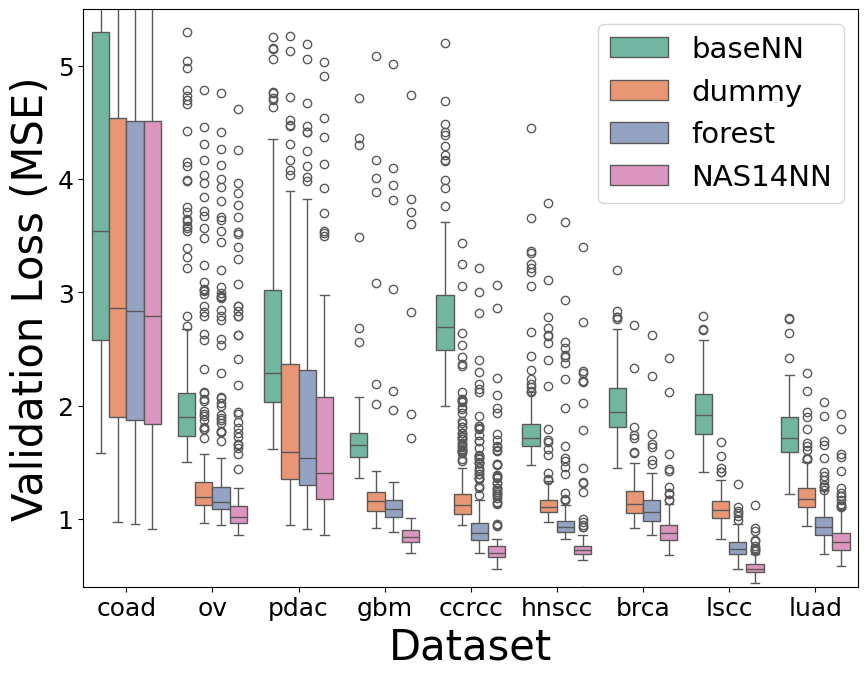

<Figure size 300x200 with 0 Axes>

In [21]:
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.boxplot(x='dataset', y='val', hue='model', data=df, palette='Set2', ax=ax)
ax.set_ylim(0.4, 5.5)

ax.set_xlabel('Dataset', fontsize=30)
ax.set_ylabel('Validation Loss (MSE)', fontsize=30)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

legend = ax.legend(fontsize=21, loc='upper right')
plt.show()
ax.legend_.remove()  # Remove the legend from the boxplot figure

fig.savefig('figure1_figures/cross_model_comparison.svg', bbox_inches='tight')

fig_legend = plt.figure(figsize=(3, 2))
labels = [text.get_text() for text in legend.texts]  # Get the actual text strings
fig_legend.legend(legend.legend_handles, labels, loc='center', fontsize=21)
fig_legend.tight_layout()
fig_legend.savefig('figure1_figures/cross_model_comparison_legend.svg', bbox_inches='tight')


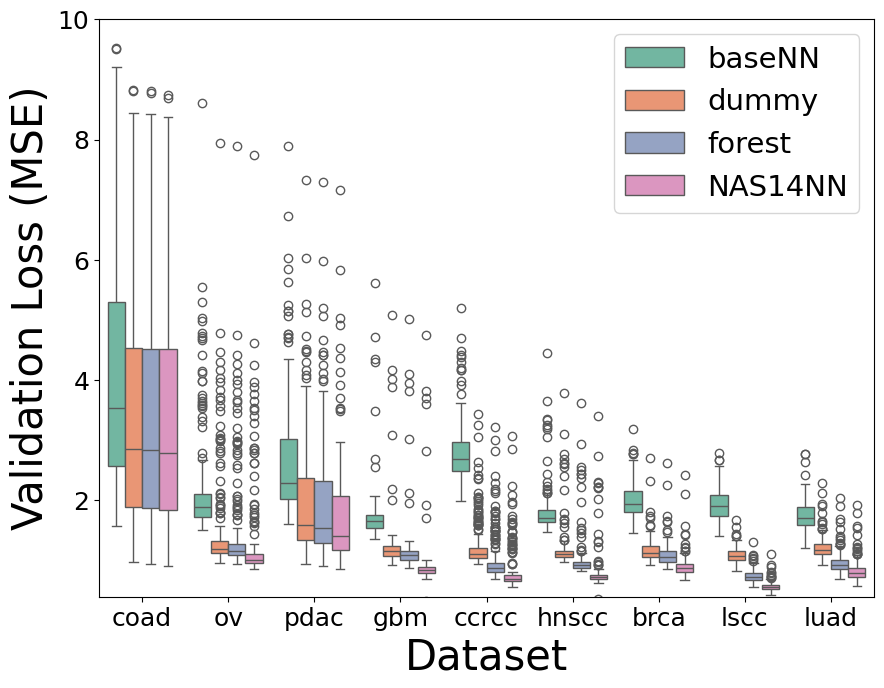

In [22]:
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.boxplot(x='dataset', y='val', hue='model', data=df, palette='Set2', ax=ax)
ax.set_ylim(0.4, 10)

ax.set_xlabel('Dataset', fontsize=30)
ax.set_ylabel('Validation Loss (MSE)', fontsize=30)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

legend = ax.legend(fontsize=21, loc='upper right')
plt.show()
#ax.legend_.remove()  # Remove the legend from the boxplot figure

fig.savefig('figure1_figures/cross_model_comparison_full.svg', bbox_inches='tight')

#fig_legend = plt.figure(figsize=(3, 2))
#labels = [text.get_text() for text in legend.texts]  # Get the actual text strings
#fig_legend.legend(legend.legendHandles, labels, loc='center', fontsize=21)
#fig_legend.tight_layout()
#fig_legend.savefig('figure1_figures/cross_model_comparison_full_legend.svg', bbox_inches='tight')


## NAS14NN Component Boxplot

<Figure size 1000x750 with 0 Axes>

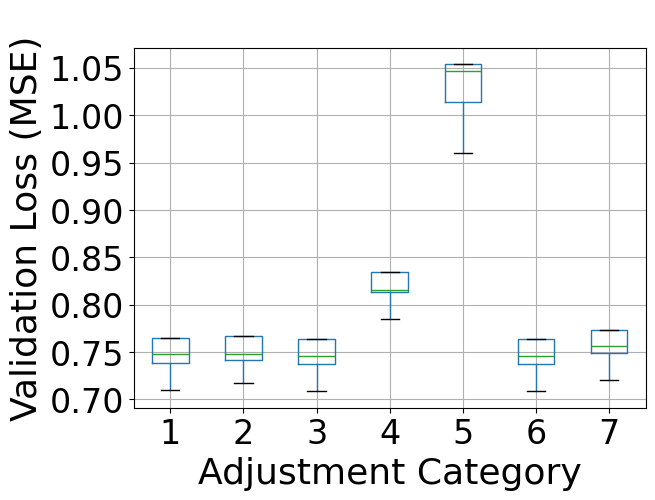

In [11]:
df = pd.read_csv('figure1_datasets/NAS14NN_run_analyses/summary.csv')

plt.figure(figsize=(10, 7.5))
boxplot = df.boxplot(column='loss', by='type', showfliers=False)
plt.suptitle('\n')
plt.title('')
plt.xlabel('Adjustment Category', fontsize=26)
plt.ylabel('Validation Loss (MSE)', fontsize=26)
boxplot.set_xticklabels(list(range(1, 8)))
#boxplot.set_xticklabels([])
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.savefig('figure1_figures/optimal_model_feature_eval.svg', bbox_inches='tight')

## NAS14 all vs individual plot

In [12]:
df = pd.read_csv('figure1_datasets/2024_03_26__5x2_output.csv')
df = df.sort_values('val',ascending=False)
#df = df[df['dataset'] != 'coad']
#df = df[df['dataset'] != 'pdac']
df = df[df['dataset'] != 'all']
#df = df[df['trainingType'] == 'justTargetDataset']
df = df[df['model'] == 'NAS14NN']
df

,dataset,datasetIteration,model,orientation,trainingType,val
1621,coad,47,NAS14NN,second,allDatasets,10.454887
1622,coad,47,NAS14NN,second,justTargetDataset,9.791994
1393,coad,41,NAS14NN,first,allDatasets,8.748593
399,coad,12,NAS14NN,first,allDatasets,8.694792
400,coad,12,NAS14NN,first,justTargetDataset,8.399299
...,...,...,...,...,...,...
875,lscc,26,NAS14NN,first,allDatasets,0.436100
3137,hnscc,91,NAS14NN,second,allDatasets,0.361287
3279,gbm,95,NAS14NN,first,allDatasets,0.332763
377,gbm,11,NAS14NN,second,allDatasets,0.320088


<Figure size 640x480 with 0 Axes>

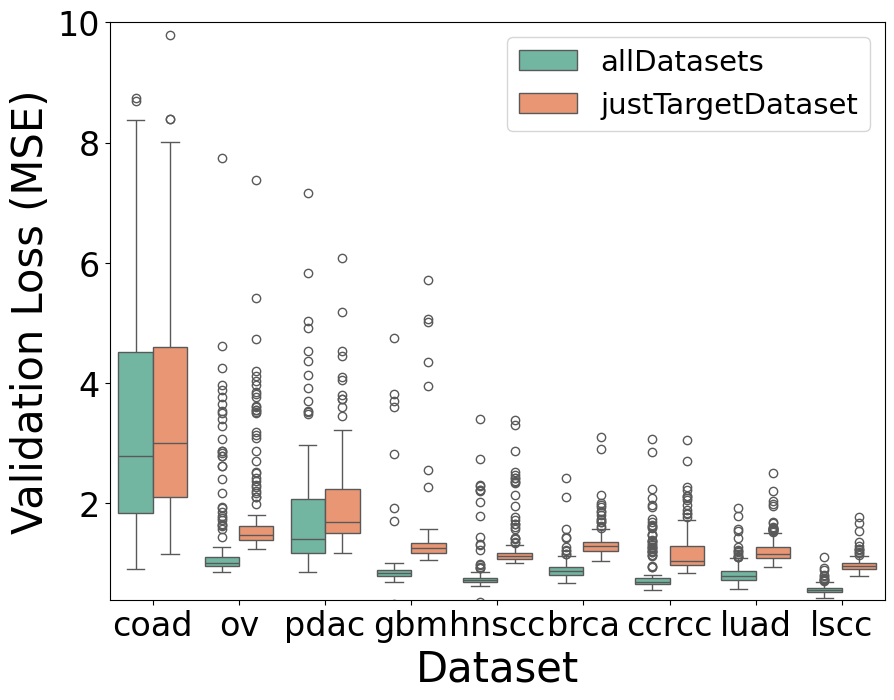

<Figure size 300x200 with 0 Axes>

In [13]:
plt.clf()
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.boxplot(x='dataset', y='val', hue='trainingType', data=df, palette='Set2', ax=ax)
ax.set_ylim(0.4, 10)

ax.set_xlabel('Dataset', fontsize=30)
ax.set_ylabel('Validation Loss (MSE)', fontsize=30)
ax.tick_params(axis='x', labelsize=24)
ax.tick_params(axis='y', labelsize=24)

legend = ax.legend(fontsize=21, loc='upper right')
plt.savefig('figure1_figures/using_all_data_in_training_comparison_all_with_legend.svg', bbox_inches='tight')
plt.show()
#ax.legend_.remove()  # Remove the legend from the boxplot figure

fig.savefig('figure1_figures/using_all_data_in_training_comparison.svg', bbox_inches='tight')

fig_legend = plt.figure(figsize=(3, 2))
labels = [text.get_text() for text in legend.texts]  # Get the actual text strings
fig_legend.legend(legend.legend_handles, labels, loc='center', fontsize=21)
fig_legend.tight_layout()
fig_legend.savefig('figure1_figures/using_all_data_in_training_comparison_legend.svg', bbox_inches='tight')
